# Linear Models

Check the performance of SVM and logistic regression on our engineered data sets before moving to more complex models.

In [2]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')
METRICS_DIR = DATA_DIR
CSV_PATH = METRICS_DIR / 'metrics.csv'
LOG = True



from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv



if LOG:
    metrics_db.read_in(CSV_PATH)

METRICS_DB_ID = 0 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "first pass" # global metric notes for this run


In [3]:
df = load_csv('linear_frame')

In [4]:
X_train, X_, y_train, y_ = train_test_split(df.drop(columns=['target']), df['target'], test_size=0.3, stratify=df['target'])
X_validate, X_test, y_validate, y_test = train_test_split(df.drop(columns=['target']), df['target'], test_size=0.5, stratify=df['target'])

In [5]:
from sklearn.model_selection import StratifiedKFold

def make_cv():
    return StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
    )



## Baseline Logistic Regression

In [6]:
from sklearn.linear_model import SGDClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

from shared_util.baseline import get_baseline_score
from imblearn.pipeline import Pipeline


print('Baseline SGD Classifier')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='sgd',
        threshold_notes='base',
        data='train',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )



Baseline SGD Classifier
roc_auc_score score per fold:  [0.56127449 0.60723351 0.58284908 0.5793362  0.58463271 0.57042415
 0.57803212 0.57446709 0.57557438 0.59091022]
mean roc_auc_score score:  0.5804733948112097
logged row: (0, sgd, train, base, under_sample)


In [7]:
# try SMOTE
from imblearn.over_sampling import SMOTE

print('Baseline ROC_AUC using SMOTE')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    SMOTE(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='sgd',
        pipeline_notes='SMOTE',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )


Baseline ROC_AUC using SMOTE
roc_auc_score score per fold:  [0.49983902 0.5        0.50466454 0.50187181 0.50014599 0.50217878
 0.50153883 0.50250064 0.50075976 0.50046793]
mean roc_auc_score score:  0.5013967290577663
logged row: (0, sgd, train, base, SMOTE)


Interestingly, baseline SGD using under sampling performed worse than baseline random forest using the same, but when using SMOTE, the linear model slightly outperformed the baseline random forest model.

In [8]:
def make_base_sgd(use_smote=False):
    return Pipeline([
        ('sampler',SMOTE(random_state=42) if use_smote else RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(random_state=42))
    ])

In [9]:
# hyperparam search for SGD
from sklearn.model_selection import RandomizedSearchCV



sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

rs = RandomizedSearchCV(
    estimator=make_base_sgd(),
    param_distributions=sgd_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=make_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True
)

rs.fit(X_train, y_train)

print(f'Best ROC_AUC (cv): {rs.best_score_}')
print(f'best params: {rs.best_params_}')

res_df = pd.DataFrame(
    rs.cv_results_
).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

KeyboardInterrupt: 

In [ ]:
# Best ROC_AUC (cv): 0.655269993641728
# best_params: {
#     'model__tol': 0.001, 
#     'model__shuffle': True, 
#     'model__penalty': 'l1', 
#     'model__max_iter': 1000, 
#     'model__loss': 'log_loss', 
#     'model__learning_rate': 'constant', 
#     'model__l1_ratio': 0.1, 
#     'model__eta0': 0.0003, ''
#     'model__class_weight': 'balanced', 
#     'model__average': False, 
#     'model__alpha': 0.0001
#     }

In [ ]:
# predict on validate set before threshold changes
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring
from shared_util.metrics.printing import print_metrics

sgd_est = rs.best_estimator_
sgd_scores = get_scores(sgd_est, X_validate)

y_pred = rs.best_estimator_.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=sgd_scores,
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              data='validate',
              model='sgd',
              hyperparam_notes='tuned best roc',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.6590642291231599
Accuracy:      0.6515675265250664
F1 score:      0.26847889923651314
Precision:     0.1762114537444934
Recall:        0.5635787249031349

Confusion matrix:

TN: 29409, FP: 14960, FN: 2478, TP: 3200

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.66      0.77     44369
           1       0.18      0.56      0.27      5678

    accuracy                           0.65     50047
   macro avg       0.55      0.61      0.52     50047
weighted avg       0.84      0.65      0.71     50047

logged row: (0, sgd_validate)


Best threshold (F2): 0.4022
Precision: 0.142  Recall: 0.832  F2: 0.423


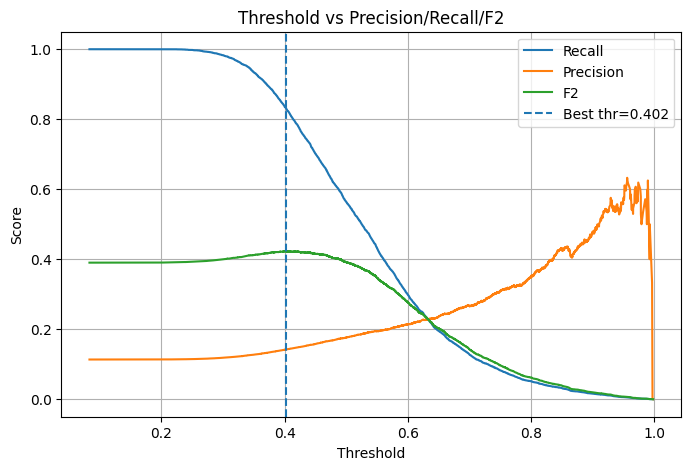

In [ ]:
# decide threshold on validation set



info = best_threshold_by_fbeta(y_validate, sgd_scores, beta=2.0)
best_thresh = info['threshold']
y_pred_custom = (sgd_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [ ]:
# use the threshold for predicitons on the held out test set

from shared_util.metrics.printing import print_metrics

sgd_scores_test = get_scores(sgd_est, X_test)

y_pred_custom_test = (sgd_scores_test >= best_thresh).astype(int)

print_metrics(
    y_true=y_test,
    y_pred=y_pred_custom_test,
    y_proba=sgd_scores_test,
    data='test',
    threshold_notes='f2_weighted',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRIC_NOTES,
    log=LOG,
    model='sgd',
    hyperparam_notes='tuned best ROC',
    pipeline_notes='under_sample'

)

ROC_AUC:     0.6599121051537301
Accuracy:      0.4099464514066496
F1 score:      0.24145282679612648
Precision:     0.14134063092051846
Recall:        0.8277562522014794

Confusion matrix:

TN: 15817, FP: 28553, FN: 978, TP: 4700

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.36      0.52     44370
           1       0.14      0.83      0.24      5678

    accuracy                           0.41     50048
   macro avg       0.54      0.59      0.38     50048
weighted avg       0.85      0.41      0.49     50048

logged row: (0, sgd_test_f2_weighted)


In [ ]:
# SVM
from sklearn.svm import SVC
from shared_util.baseline import get_baseline_score

roc_auc = get_baseline_score(
    SVC(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
)

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='svc',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )






roc_auc_score score per fold:  [0.59721041 0.62894125 0.60514504 0.61414274 0.6286531  0.61659853
 0.60707986 0.61531246 0.59549865 0.6034131 ]
mean roc_auc_score score:  0.6111995141953734
logged row: (0, svc_base_undsampl)


In [ ]:
# running smote did not get a result after 6 hours so leaving it out for now

## Hyperparameter sweep for SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV #type: ignore
from scipy.stats import loguniform



def make_base_svc():
    return Pipeline([
        ('sampler', RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42, cache_size=16384, probability=True))
    ])
# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf", "poly"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

# reduced to 5 folds again for computation time

cv_svc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

rs_hsvc = HalvingRandomSearchCV(
    estimator=make_base_svc(),
    param_distributions=svc_param_grid,
   # n_iter=50,  
    scoring='roc_auc',
    cv=make_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rs_svc = RandomizedSearchCV(
    estimator=make_base_svc(),
    param_distributions=svc_param_grid,
    n_iter=50,  
    scoring='roc_auc',
    cv=cv_svc,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=2  # Show progress since SVC is slow
)

rs_hsvc.fit(X_train, y_train)

print(f'Best ROC_AUC (cv): {rs_hsvc.best_score_}')
print(f'Best params: {rs_hsvc.best_params_}')

res_df = pd.DataFrame(rs_hsvc.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 40
max_resources_: 70066
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1751
n_resources: 40
Fitting 10 folds for each of 1751 candidates, totalling 17510 fits
----------
iter: 1
n_candidates: 584
n_resources: 120
Fitting 10 folds for each of 584 candidates, totalling 5840 fits
----------
iter: 2
n_candidates: 195
n_resources: 360
Fitting 10 folds for each of 195 candidates, totalling 1950 fits
----------
iter: 3
n_candidates: 65
n_resources: 1080
Fitting 10 folds for each of 65 candidates, totalling 650 fits
----------
iter: 4
n_candidates: 22
n_resources: 3240
Fitting 10 folds for each of 22 candidates, totalling 220 fits
----------
iter: 5
n_candidates: 8
n_resources: 9720
Fitting 10 folds for each of 8 candidates, totalling 80 fits
----------
iter: 6
n_candidates: 3
n_resources: 29160
Fitting 10 folds for each of 3 candidates, totalling 30 fits
Best ROC_AUC (cv): 0.6333948470

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.633395,0.021494,"{'model__C': 0.1768787611314103, 'model__class..."
1,2,0.627497,0.021464,"{'model__C': 0.1052008039152057, 'model__class..."
2,3,0.625476,0.021535,"{'model__C': 0.09166403471455101, 'model__clas..."
3,4,0.613420,0.027029,"{'model__C': 0.1768787611314103, 'model__class..."
4,5,0.604820,0.028277,"{'model__C': 0.1052008039152057, 'model__class..."
5,6,0.602020,0.028911,"{'model__C': 0.09166403471455101, 'model__clas..."
6,7,0.594014,0.030153,"{'model__C': 0.03790316006121245, 'model__clas..."
7,7,0.594014,0.030153,"{'model__C': 0.0014251231497686534, 'model__cl..."
8,7,0.594014,0.030153,"{'model__C': 0.04154298215861666, 'model__clas..."
9,7,0.594014,0.030153,"{'model__C': 0.004024092992668076, 'model__cla..."


In [ ]:
# The above code block generates best hyperparams for our SVC model:

# Best ROC_AUC (cv): 0.6333948470860357
# Best params: {'model__C': np.float64(0.1768787611314103), 'model__class_weight': 'balanced', 'model__gamma': 0.01, 'model__kernel': 'rbf', 'model__shrinking': False}

In [ ]:
# predict on validate set before threshold changes
svm_est = rs_hsvc.best_estimator_
svm_scores = get_scores(svm_est, X_validate)

y_pred = svm_est.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=svm_scores,
              data='validate',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.661743981639901
Accuracy:      0.640218194896797
F1 score:      0.26619936425136526
Precision:     0.17317073170731706
Recall:        0.5752025361042621

Confusion matrix:

TN: 28775, FP: 15594, FN: 2412, TP: 3266

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.65      0.76     44369
           1       0.17      0.58      0.27      5678

    accuracy                           0.64     50047
   macro avg       0.55      0.61      0.51     50047
weighted avg       0.84      0.64      0.71     50047

logged row: (0, svc_validate)


Best threshold (F2): 0.3982
Precision: 0.145  Recall: 0.823  F2: 0.426


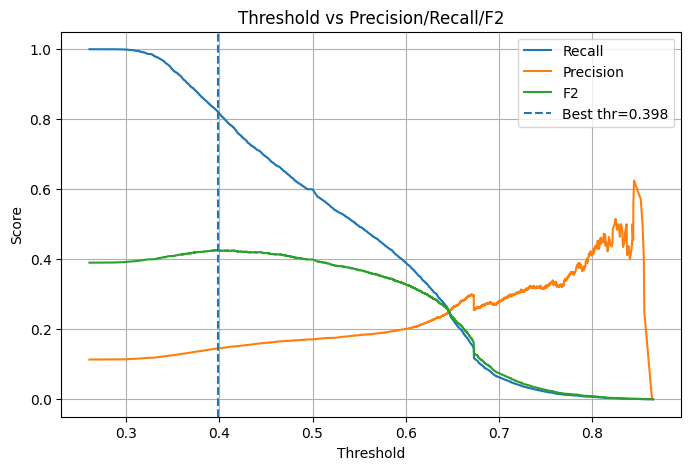

In [ ]:
# threshold sweep using validation set
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring



info = best_threshold_by_fbeta(y_validate, svm_scores, beta=2.0)

best_thresh = info["threshold"]
y_pred_custom = (svm_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [ ]:
# held out test prediction using calculated threshold

# this inference took ~25 seconds, considering other models took <1 second, thats a significant downside to SVC

svm_scores_test = get_scores(svm_est, X_test)

y_pred_test_svm = (svm_scores_test >= best_thresh).astype(int)


In [ ]:
from shared_util.metrics.printing import print_metrics

print ('Held out test metrics for (Support Vector Classifier)')

print_metrics(
              y_true=y_test, 
              y_pred=y_pred_test_svm, 
              y_proba=svm_scores_test,
              data='test',
              threshold_notes='f2_weighted',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
              )

Held out test metrics for (Support Vector Classifier)
ROC_AUC:     0.6627452607809875
Accuracy:      0.4304667519181586
F1 score:      0.2477170757455793
Precision:     0.14569104681485162
Recall:        0.8265234237407538

Confusion matrix:

TN: 16851, FP: 27519, FN: 985, TP: 4693

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.38      0.54     44370
           1       0.15      0.83      0.25      5678

    accuracy                           0.43     50048
   macro avg       0.55      0.60      0.39     50048
weighted avg       0.85      0.43      0.51     50048

logged row: (0, svc_test_f2_weighted)


Both SVM and the SGD classifier both achieved above expected results compared to previous literature, which showed linear models performing, generally, with a ROC_AUC below 0.600.

